In [20]:
import sys
print(sys.version)
print(sys.executable)

3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
/home/mack-pol/miniconda3/envs/cudaq-env/bin/python


In [21]:
# This cell is added by sphinx-gallery
# It can be customized to whatever you like
%matplotlib inline

In [35]:
import numpy as np
import pennylane as qml

In [38]:
import numpy as np
import pennylane as qml
import pubchempy as pcp

In [23]:
def generate_molecule_data(molecules="H2"):
    datasets = qml.data.load("qchem", molname=molecules)

    # Get the time set T
    op_times = np.sort(np.array([-2**k for k in range(1, 5)] + [2**k for k in range(1, 5)]) / 160)

    # Build operator set P for each molecule
    molecule_data = dict()
    for dataset in datasets:
        molecule = dataset.molecule
        num_electrons, num_qubits = molecule.n_electrons, 2 * molecule.n_orbitals
        singles, doubles = qml.qchem.excitations(num_electrons, num_qubits)
        double_excs = [qml.DoubleExcitation(time, wires=double) for double in doubles for time in op_times]
        single_excs = [qml.SingleExcitation(time, wires=single) for single in singles for time in op_times]
        identity_ops = [qml.exp(qml.I(range(num_qubits)), 1j*time) for time in op_times] # For Identity
        operator_pool = double_excs + single_excs + identity_ops
        molecule_data[dataset.molname] = {
            "op_pool": np.array(operator_pool), 
            "num_qubits": num_qubits,
            "hf_state": dataset.hf_state,
            "hamiltonian": dataset.hamiltonian,
            "expected_ground_state_E": dataset.fci_energy
        }
    return molecule_data

molecule_data = generate_molecule_data("H2")
h2_data = molecule_data["H2"]
op_pool = h2_data["op_pool"]
num_qubits = h2_data["num_qubits"]
init_state = h2_data["hf_state"]
hamiltonian = h2_data["hamiltonian"]
grd_E = h2_data["expected_ground_state_E"]
op_pool_size = len(op_pool)
print(num_qubits)

4


# data visualization

Number of molecular orbitals: 2
Number of electrons: 2
Number of qubits: 4
Hartree-Fock state: [1 1 0 0]


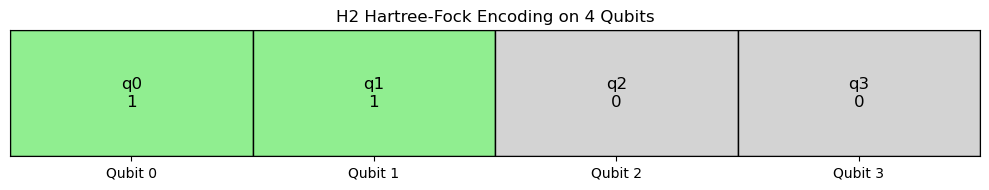

In [25]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

def generate_molecule_data(molecules="H2"):
    datasets = qml.data.load("qchem", molname=molecules)

    op_times = np.sort(
        np.array([-2**k for k in range(1, 5)] + [2**k for k in range(1, 5)]) / 160
    )

    molecule_data = dict()

    for dataset in datasets:
        molecule = dataset.molecule

        num_electrons = molecule.n_electrons
        num_qubits = 2 * molecule.n_orbitals

        singles, doubles = qml.qchem.excitations(
            num_electrons,
            num_qubits
        )

        molecule_data[dataset.molname] = {
            "num_qubits": num_qubits,
            "num_electrons": num_electrons,
            "n_orbitals": molecule.n_orbitals,
            "singles": singles,
            "doubles": doubles,
            "hf_state": dataset.hf_state,
        }

    return molecule_data

# Generate data
molecule_data = generate_molecule_data("H2")
h2_data = molecule_data["H2"]

# Extract information
num_qubits = h2_data["num_qubits"]
num_electrons = h2_data["num_electrons"]
n_orbitals = h2_data["n_orbitals"]
hf_state = h2_data["hf_state"]

print("Number of molecular orbitals:", n_orbitals)
print("Number of electrons:", num_electrons)
print("Number of qubits:", num_qubits)
print("Hartree-Fock state:", hf_state)

# Visualization
fig, ax = plt.subplots(figsize=(10, 2))

for i in range(num_qubits):

    if hf_state[i] == 1:
        color = "lightgreen"
        label = "Occupied"
    else:
        color = "lightgray"
        label = "Empty"

    rect = plt.Rectangle((i, 0), 1, 1, color=color, ec='black')
    ax.add_patch(rect)

    ax.text(
        i + 0.5,
        0.5,
        f"q{i}\n{hf_state[i]}",
        ha='center',
        va='center',
        fontsize=12
    )

ax.set_xlim(0, num_qubits)
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(num_qubits) + 0.5)
ax.set_xticklabels([f"Qubit {i}" for i in range(num_qubits)])

ax.set_yticks([])

plt.title("H2 Hartree-Fock Encoding on 4 Qubits")
plt.tight_layout()
plt.show()

In [6]:
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev)
def energy_circuit(gqe_ops):
    # Computes Eq. 1 from Nakaji et al. based on the selected unitary operators
    qml.BasisState(init_state, wires=range(num_qubits)) # Initial state <-- Hartree Fock state
    for op in gqe_ops:
        qml.Snapshot(measurement=qml.expval(hamiltonian))
        qml.apply(op) # Applies each of the unitary operators
    return qml.expval(hamiltonian)

energy_circuit = qml.snapshots(energy_circuit)

def get_subsequence_energies(op_seq):
    # Collates the energies of each subsequence for a batch of sequences
    energies = []
    for ops in op_seq:
        es = energy_circuit(ops)
        energies.append(
            [es[k].item() for k in list(range(1, len(ops))) + ["execution_results"]]
        )
    return np.array(energies)

In [7]:
# Generate sequence of indices of operators in vocab
train_size = 1024
seq_len = 4
train_op_pool_inds = np.random.randint(op_pool_size, size=(train_size, seq_len))

# Corresponding sequence of operators
train_op_seq = op_pool[train_op_pool_inds]

# Corresponding tokens with special starting tokens
train_token_seq = np.concatenate([
    np.zeros(shape=(train_size, 1), dtype=int), # starting token is 0
    train_op_pool_inds + 1 # shift operator inds by one
], axis=1)

# Calculate the energies for each subsequence in the training set
train_sub_seq_en = get_subsequence_energies(train_op_seq)

In [8]:
!curl -O https://raw.githubusercontent.com/karpathy/nanoGPT/master/model.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16345  100 16345    0     0  88084      0 --:--:-- --:--:-- --:--:-- 88351


In [9]:
# !curl -O https://raw.githubusercontent.com/karpathy/nanoGPT/master/model.py
from model import GPT, GPTConfig
import torch
from torch.nn import functional as F

class GPTQE(GPT):
    def forward(self, idx):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits
    
    def calculate_loss(self, tokens, energies):
        current_tokens, next_tokens = tokens[:, :-1], tokens[:, 1:]
        # calculate the logits for the next possible tokens in the sequence
        logits = self(current_tokens)
        # get the logit for the actual next token in the sequence
        next_token_mask = torch.nn.functional.one_hot(
            next_tokens, num_classes=self.config.vocab_size
        )
        next_token_logits = (logits * next_token_mask).sum(axis=2)
        # calculate the cumulative logits for each subsequence
        cumsum_logits = torch.cumsum(next_token_logits, dim=1)
        # match cumulative logits to subsequence energies
        loss = torch.mean(torch.square(cumsum_logits - energies))
        return loss
    
    @torch.no_grad()
    def generate(self, n_sequences, max_new_tokens, temperature=1.0, device="cpu"):
        idx = torch.zeros(size=(n_sequences, 1), dtype=int, device=device)
        total_logits = torch.zeros(size=(n_sequences, 1), device=device)
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits = self(idx_cond)
            # pluck the logits at the final step 
            logits = logits[:, -1, :] 
            # set the logit of the first token so that its probability will be zero
            logits[:, 0] = float("inf")
            # apply softmax to convert logits to (normalized) probabilities and scale by desired temperature
            probs = F.softmax(-logits / temperature, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # # Accumulate logits
            total_logits += torch.gather(logits, index=idx_next, dim=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)
        return idx, total_logits

In [10]:
tokens = torch.from_numpy(train_token_seq).to("cuda")
energies = torch.from_numpy(train_sub_seq_en).to("cuda")

gpt = GPTQE(GPTConfig(
    vocab_size=op_pool_size + 1,
    block_size=seq_len,
    dropout=0.2,
    bias=False
)).to("cuda")
opt = gpt.configure_optimizers(
    weight_decay=0.01, learning_rate=5e-5, betas=(0.9, 0.999), device_type="cuda"
)


number of parameters: 84.98M
num decayed parameter tensors: 50, with 84,963,072 parameters
num non-decayed parameter tensors: 25, with 19,200 parameters
using fused AdamW: True


In [11]:
import torch
print(torch.cuda.is_available())      # should print True
print(torch.cuda.get_device_name(0))  # should print your GPU name

True
NVIDIA GeForce GTX 1650


In [12]:
import os
os.makedirs(f"./seq_len={seq_len}", exist_ok=True)

In [13]:
import os
import pandas as pd

trial_name = "trial7"
save_dir = f"./seq_len={seq_len}/{trial_name}"
os.makedirs(save_dir, exist_ok=True)

n_batches = 8
train_inds = np.arange(train_size)
losses = []
pred_Es_t = []
true_Es_t = []
current_mae = 10000
gpt.train()

for i in range(10000):
    np.random.shuffle(train_inds)
    token_batches = torch.tensor_split(tokens[train_inds], n_batches)
    energy_batches = torch.tensor_split(energies[train_inds], n_batches)
    
    loss_record = 0
    for token_batch, energy_batch in zip(token_batches, energy_batches):
        opt.zero_grad()
        loss = gpt.calculate_loss(token_batch, energy_batch)
        loss.backward()
        opt.step()
        loss_record += loss.item() / n_batches
    losses.append(loss_record)

    if (i+1) % 500 == 0:
        gpt.eval()
        gen_token_seq, pred_Es = gpt.generate(
            n_sequences=100, 
            max_new_tokens=seq_len, 
            temperature=0.001,
            device="cuda"
        )
        pred_Es = pred_Es.cpu().numpy()
        gen_inds = (gen_token_seq[:, 1:] - 1).cpu().numpy()
        gen_op_seq = op_pool[gen_inds]
        true_Es = get_subsequence_energies(gen_op_seq)[:, -1].reshape(-1, 1)
        mae = np.mean(np.abs(pred_Es - true_Es))
        ave_E = np.mean(true_Es)
        
        pred_Es_t.append(pred_Es)
        true_Es_t.append(true_Es)
        
        print(f"Iteration: {i+1}, Loss: {losses[-1]}, MAE: {mae}, Ave E: {ave_E}")
        
        if mae < current_mae:
            current_mae = mae
            torch.save(gpt, f"{save_dir}/gqe.pt")
            print("Saved model!")
            
        gpt.train()

pred_Es_t = np.concatenate(pred_Es_t, axis=1)
true_Es_t = np.concatenate(true_Es_t, axis=1)

# Only change: add column names so x-axis is correct in the plot
checkpoint_cols = list(range(500, 10001, 500))  # [500, 1000, ..., 10000]

pd.DataFrame(losses).to_csv(f"{save_dir}/losses.csv")
pd.DataFrame(pred_Es_t, columns=checkpoint_cols).to_csv(f"{save_dir}/pred_Es_t.csv")
pd.DataFrame(true_Es_t, columns=checkpoint_cols).to_csv(f"{save_dir}/true_Es_t.csv")
print(f"Results saved to {save_dir}/")

Iteration: 500, Loss: 0.004255437473594272, MAE: 0.07053555043899976, Ave E: -1.1305255195263628
Saved model!
Iteration: 1000, Loss: 0.001817226664886163, MAE: 0.10847013573551724, Ave E: -1.1246652843484823
Iteration: 1500, Loss: 0.0005122720842061554, MAE: 0.05925655378573322, Ave E: -1.127219445569583
Saved model!
Iteration: 2000, Loss: 0.00018452809969288328, MAE: 0.04469340908812067, Ave E: -1.1365381087036273
Saved model!
Iteration: 2500, Loss: 0.00011513007655351752, MAE: 0.059523325230540436, Ave E: -1.1334048554640395
Iteration: 3000, Loss: 0.00035724070297506335, MAE: 0.06990652091834669, Ave E: -1.1257134556021913
Iteration: 3500, Loss: 3.6936063878403584e-05, MAE: 0.019486651755515113, Ave E: -1.133828031681832
Saved model!
Iteration: 4000, Loss: 1.6162083685842468e-05, MAE: 0.01455272000027296, Ave E: -1.1350531919698654
Saved model!
Iteration: 4500, Loss: 2.584560460566119e-05, MAE: 0.008800697696272255, Ave E: -1.136480676758226
Saved model!
Iteration: 5000, Loss: 9.1367

:Curve   [index]   (0)
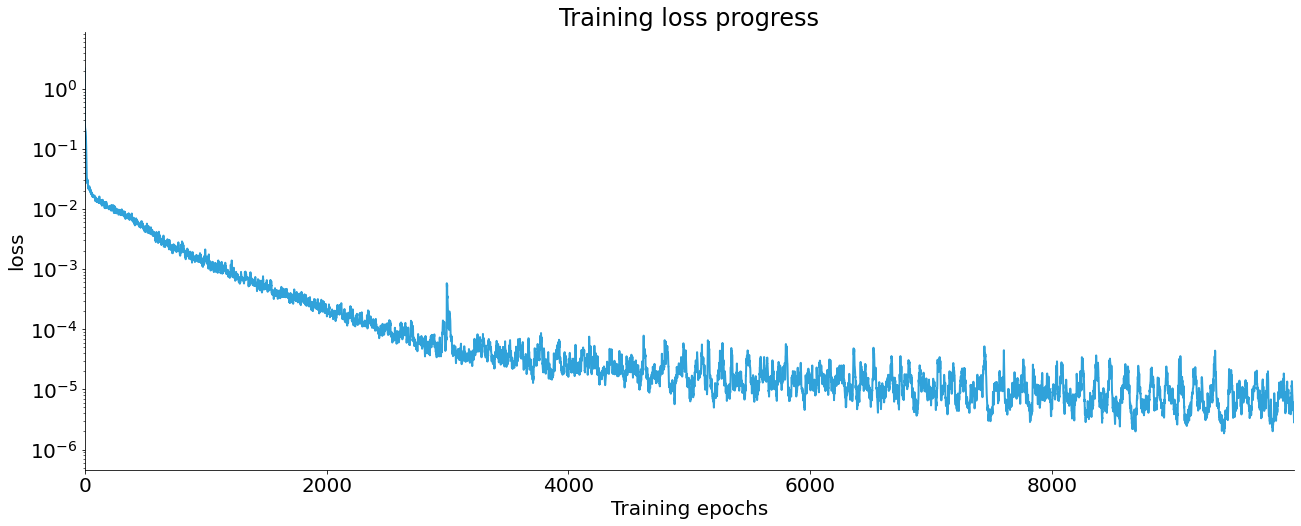

In [14]:
import holoviews as hv
import hvplot.pandas
import pandas as pd

hvplot.extension('matplotlib')

losses = pd.read_csv("./seq_len=4/trial7/losses.csv")["0"]
loss_fig = losses.hvplot(
    title="Training loss progress", ylabel="loss", xlabel="Training epochs", logy=True
).opts(fig_size=600, fontscale=2, aspect=1.2)
loss_fig

:Overlay
   .Scatter.Mean_True_Energies      :Scatter   [Training Iterations]   (Ave True E)
   .Curve.I                         :Curve   [Training Iterations]   (Ave True E)
   .Area.I                          :Area   [Training Iterations]   (Min True E,Max True E)
   .Scatter.Mean_Predicted_Energies :Scatter   [Training Iterations]   (Ave Pred E)
   .Curve.II                        :Curve   [Training Iterations]   (Ave Pred E)
   .Area.II                         :Area   [Training Iterations]   (Min Pred E,Max Pred E)
   .Curve.Ground_State_Energy       :Curve   [x]   (y)
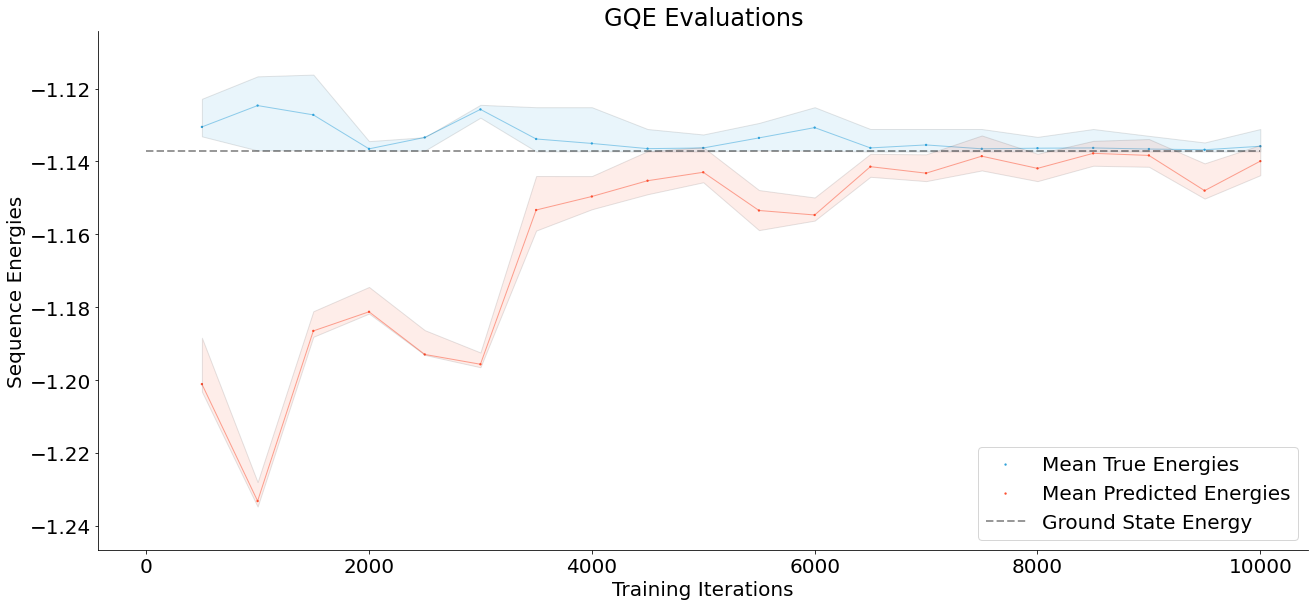

In [16]:
df_true = pd.read_csv("./seq_len=4/trial7/true_Es_t.csv").iloc[:, 1:]
df_pred = pd.read_csv("./seq_len=4/trial7/pred_Es_t.csv").iloc[:, 1:]

df_true.columns = df_true.columns.astype(int)
df_pred.columns = df_pred.columns.astype(int)

df_trues_stats = pd.concat([df_true.mean(axis=0), df_true.min(axis=0), df_true.max(axis=0)], axis=1).reset_index()
df_trues_stats.columns = ["Training Iterations", "Ave True E", "Min True E", "Max True E"]

df_preds_stats = pd.concat([df_pred.mean(axis=0), df_pred.min(axis=0), df_pred.max(axis=0)], axis=1).reset_index()
df_preds_stats.columns = ["Training Iterations", "Ave Pred E", "Min Pred E", "Max Pred E"]

fig = (
    df_trues_stats.hvplot.scatter(x="Training Iterations", y="Ave True E", label="Mean True Energies") *
    df_trues_stats.hvplot.line(x="Training Iterations", y="Ave True E", alpha=0.5, linewidth=1) *
    df_trues_stats.hvplot.area(x="Training Iterations", y="Min True E", y2="Max True E", alpha=0.1)
) * (
    df_preds_stats.hvplot.scatter(x="Training Iterations", y="Ave Pred E", label="Mean Predicted Energies") *
    df_preds_stats.hvplot.line(x="Training Iterations", y="Ave Pred E", alpha=0.5, linewidth=1) *
    df_preds_stats.hvplot.area(x="Training Iterations", y="Min Pred E", y2="Max Pred E", alpha=0.1)
)
fig = fig * hv.Curve([[0, grd_E], [10000, grd_E]], label="Ground State Energy").opts(color="k", alpha=0.4, linestyle="dashed")
fig = fig.opts(ylabel="Sequence Energies", title="GQE Evaluations", fig_size=600, fontscale=2)
fig

In [17]:
# Latest model
gen_token_seq_, _ = gpt.generate(
    n_sequences=1024, 
    max_new_tokens=seq_len, 
    temperature=0.001, 
    device="cuda"
)
gen_inds_ = (gen_token_seq_[:, 1:] - 1).cpu().numpy()
gen_op_seq_ = op_pool[gen_inds_]
true_Es_ = get_subsequence_energies(gen_op_seq_)[:, -1].reshape(-1, 1)

# Best model
loaded = torch.load("./seq_len=4/trial7/gqe.pt", weights_only=False)
loaded_token_seq_, _ = loaded.generate(
    n_sequences=1024, 
    max_new_tokens=seq_len, 
    temperature=0.001, 
    device="cuda"
)
loaded_inds_ = (loaded_token_seq_[:, 1:] - 1).cpu().numpy()
loaded_op_seq_ = op_pool[loaded_inds_]
loaded_true_Es_ = get_subsequence_energies(loaded_op_seq_)[:, -1].reshape(-1, 1)

# Summary table
df_compare_Es = pd.DataFrame({
    "Source": ["Random", "Latest Model", "Best Model"], 
    "Aves": [train_sub_seq_en[:, -1].mean(), true_Es_.mean(), loaded_true_Es_.mean()],
    "Mins": [train_sub_seq_en[:, -1].min(), true_Es_.min(), loaded_true_Es_.min()],
    "Maxs": [train_sub_seq_en[:, -1].max(), true_Es_.max(), loaded_true_Es_.max()],
    "Mins_error": [
        abs(train_sub_seq_en[:, -1].min() - grd_E),
        abs(true_Es_.min() - grd_E),
        abs(loaded_true_Es_.min() - grd_E),
    ],
})
df_compare_Es

,Source,Aves,Mins,Maxs,Mins_error
0,Random,-1.114556,-1.136865,-1.058932,3.981481e-04
1,Latest Model,-1.134829,-1.137263,-1.125118,7.712067e-07
2,Best Model,-1.136535,-1.137263,-1.130701,7.712067e-07
